In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
os.environ["PATH"] = "/vast/palmer/apps/avx2/software/texlive/20220321-GCC-12.2.0/bin/x86_64-linux:" + os.environ["PATH"]
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{lmodern}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "figure.figsize": [8, 5.6],
    "svg.fonttype": "none",
    "image.cmap": "viridis",
})

In [4]:
JAMMED_DATA_DIR = Path("/home/rg2248/project/friction/data/local-friction/uniform/jammed")
SAMPLED_DATA_DIR = Path("/home/rg2248/project/friction/data/local-friction/uniform/sample")

In [5]:
def load_data(data_dir):
    files = sorted(
        data_dir.glob("mu-*.npz"),
        key=lambda path: float(path.stem.removeprefix("mu-")),
    )

    return {
        float(path.stem.removeprefix("mu-")): dict(np.load(path))
        for path in files
    }

jammed_data = load_data(JAMMED_DATA_DIR)
sampled_data = load_data(SAMPLED_DATA_DIR)

mu_eff = np.array(sorted(jammed_data.keys() & sampled_data.keys()))
data = jammed_data

In [6]:
for value in mu_eff:
    jammed = jammed_data[value]
    sampled = sampled_data[value]

    print(
        f"μeff={value:g}  "
        f"Jammed={len(jammed['all'])}  "
        f"Probed SS={len(sampled['ss'])}  "
        f"SL={len(sampled['sl'])}  "
        f"LL={len(sampled['ll'])}"
    )

μeff=0.01  Jammed=26630  Probed SS=25060027  SL=25060027  LL=25060027
μeff=0.03  Jammed=36209  Probed SS=25060027  SL=25060027  LL=25060027
μeff=0.05  Jammed=36037  Probed SS=25060027  SL=25060027  LL=25060027
μeff=0.1  Jammed=35525  Probed SS=25060027  SL=25060027  LL=25060027
μeff=0.3  Jammed=32614  Probed SS=25060027  SL=25060027  LL=25060027
μeff=0.5  Jammed=30266  Probed SS=25060027  SL=25060027  LL=25060027
μeff=1  Jammed=28420  Probed SS=25060027  SL=25060027  LL=25060027


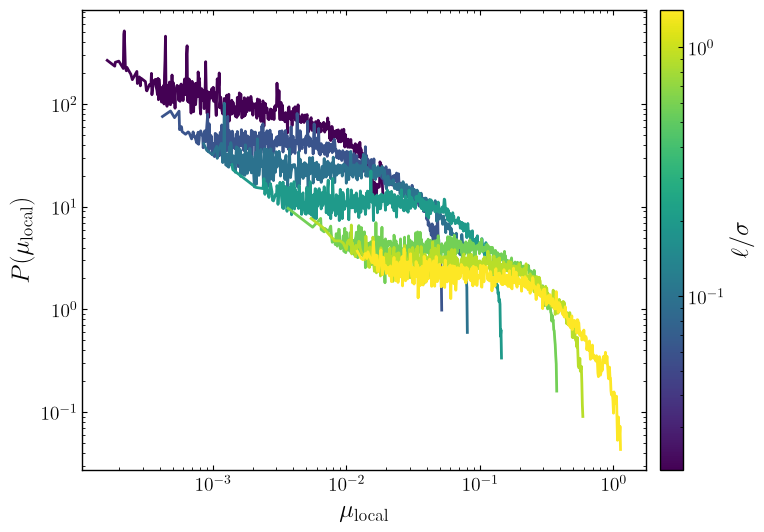

In [7]:
from matplotlib.colors import LogNorm

l_over_sigma = 2 * mu_eff / np.sqrt(1 + mu_eff**2)
min_count = 10

def positive(values):
    return values[np.isfinite(values) & (values > 0)]

positive_values = np.concatenate([
    positive(jammed_data[value]["all"])
    for value in mu_eff
])

bins = np.logspace(
    np.log10(positive_values.min()),
    np.log10(positive_values.max()),
    2000,
)

centers = np.sqrt(bins[:-1] * bins[1:])
norm = LogNorm(l_over_sigma.min(), l_over_sigma.max())
cmap = plt.get_cmap("viridis")

def density(values):
    values = positive(values)
    counts, _ = np.histogram(values, bins=bins)
    probability = counts / (len(values) * np.diff(bins))
    return probability, counts

fig, ax = plt.subplots()

for value, ratio in zip(mu_eff, l_over_sigma):
    probability, counts = density(jammed_data[value]["all"])
    mask = counts >= min_count

    ax.plot(
        centers[mask],
        probability[mask],
        color=cmap(norm(ratio)),
    )

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    pad=0.02,
)

colorbar.set_label(r"$\ell/\sigma$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\mu_{\mathrm{local}}$")
ax.set_ylabel(r"$P(\mu_{\mathrm{local}})$")
plt.tight_layout()
plt.savefig("../../figures/friction/uniform/jammed-distributions.png", dpi=600, bbox_inches="tight")
plt.show()

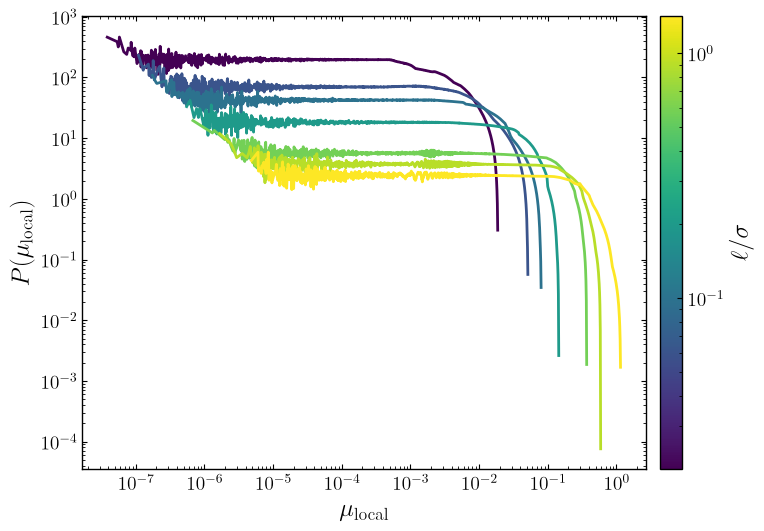

In [8]:
from matplotlib.colors import LogNorm

l_over_sigma = 2 * mu_eff / np.sqrt(1 + mu_eff**2)
min_count = 10

def positive(values):
    return values[np.isfinite(values) & (values > 0)]

positive_values = np.concatenate([
    positive(sampled_data[value][key])
    for value in mu_eff
    for key in ("ss", "sl", "ll")
])

bins = np.logspace(
    np.log10(positive_values.min()),
    np.log10(positive_values.max()),
    2000,
)

centers = np.sqrt(bins[:-1] * bins[1:])
norm = LogNorm(l_over_sigma.min(), l_over_sigma.max())
cmap = plt.get_cmap("viridis")

def density(values):
    values = positive(values)
    counts, _ = np.histogram(values, bins=bins)
    probability = counts / (len(values) * np.diff(bins))
    return probability, counts

fig, ax = plt.subplots()

for value, ratio in zip(mu_eff, l_over_sigma):
    ss_probability, ss_counts = density(sampled_data[value]["ss"])
    sl_probability, sl_counts = density(sampled_data[value]["sl"])
    ll_probability, ll_counts = density(sampled_data[value]["ll"])

    probability = (
        0.25 * ss_probability
        + 0.50 * sl_probability
        + 0.25 * ll_probability
    )

    counts = ss_counts + sl_counts + ll_counts

    mask = counts >= min_count

    ax.plot(
        centers[mask],
        probability[mask],
        color=cmap(norm(ratio)),
    )

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    pad=0.02,
)

colorbar.set_label(r"$\ell/\sigma$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\mu_{\mathrm{local}}$")
ax.set_ylabel(r"$P(\mu_{\mathrm{local}})$")
plt.tight_layout()
plt.savefig("../../figures/friction/uniform/sampled-distributions.png", dpi=600, bbox_inches="tight")
plt.show()

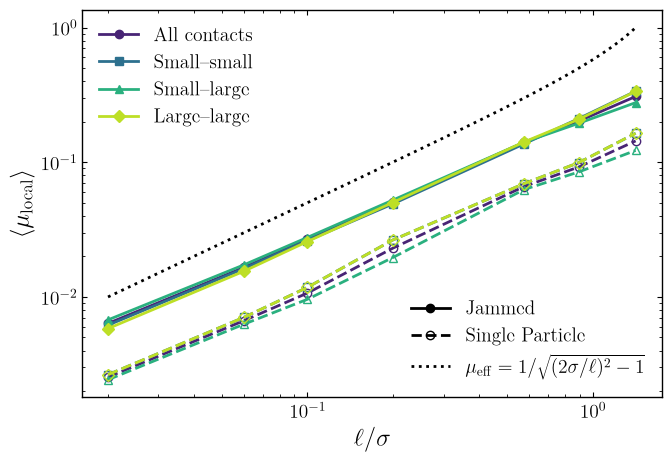

In [9]:
from scipy.stats import gmean

def positive(values):
    values = np.asarray(values)
    return values[np.isfinite(values) & (values > 0)]

contact_types = {
    "all": ("All contacts", "o"),
    "ss": ("Small--small", "s"),
    "sl": ("Small--large", "^"),
    "ll": ("Large--large", "D"),
}

order = np.argsort(l_over_sigma)
x = l_over_sigma[order]
colors = plt.get_cmap("viridis")(np.linspace(0.1, 0.9, len(contact_types)))

jammed_means = {
    key: np.array([
        jammed_data[value][key].mean()
        for value in mu_eff
    ])[order]
    for key in contact_types
}

sampled_means = {
    key: np.array([
        sampled_data[value][key].mean()
        for value in mu_eff
    ])[order]
    for key in ("ss", "sl", "ll")
}

sampled_means["all"] = np.array([
    sum(
        len(jammed_data[value][key]) / len(jammed_data[value]["all"])
        * sampled_data[value][key].mean()
        for key in ("ss", "sl", "ll")
    )
    for value in mu_eff
])[order]

# jammed_means = {
#     key: np.array([
#         gmean(positive(jammed_data[value][key]))
#         for value in mu_eff
#     ])[order]
#     for key in contact_types
# }

# sampled_means = {
#     key: np.array([
#         gmean(positive(sampled_data[value][key]))
#         for value in mu_eff
#     ])[order]
#     for key in ("ss", "sl", "ll")
# }

# sampled_means["all"] = np.array([
#     np.exp(sum(
#         len(jammed_data[value][key]) / len(jammed_data[value]["all"])
#         * np.mean(np.log(positive(sampled_data[value][key])))
#         for key in ("ss", "sl", "ll")
#     ))
#     for value in mu_eff
# ])[order]

fig, ax = plt.subplots(figsize=(7, 4.9))
contact_handles = []

for (key, (label, marker)), color in zip(contact_types.items(), colors):
    jammed_line = ax.plot(
        x,
        jammed_means[key],
        color=color,
        marker=marker,
        linestyle="-",
        label=label,
    )[0]

    ax.plot(
        x,
        sampled_means[key],
        color=color,
        marker=marker,
        markerfacecolor="none",
        linestyle="--",
    )

    contact_handles.append(jammed_line)

x_theory = np.logspace(np.log10(x.min()), np.log10(x.max()), 500)
mu_theory = x_theory / np.sqrt(4 - x_theory**2)

theory_line = ax.plot(
    x_theory,
    mu_theory,
    color="black",
    linestyle=":",
    label=r"$\mu_{\mathrm{eff}}=1/\sqrt{(2\sigma/\ell)^2-1}$",
)[0]

contact_legend = ax.legend(
    handles=contact_handles,
    frameon=False,
    loc="upper left",
)
ax.add_artist(contact_legend)

source_handles = [
    ax.plot([], [], color="black", linestyle="-", marker="o", label="Jammed")[0],
    ax.plot(
        [],
        [],
        color="black",
        linestyle="--",
        marker="o",
        markerfacecolor="none",
        label="Single Particle",
    )[0],
    theory_line,
]

ax.legend(handles=source_handles, frameon=False, loc="lower right")
ax.set_xlabel(r"$\ell/\sigma$")
ax.set_ylabel(r"$\langle\mu_{\mathrm{local}}\rangle$")
# ax.set_ylabel(r"$GM(\mu_{\mathrm{local}})$")
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig("../../figures/friction/uniform/mean-mu.png", dpi=600, bbox_inches="tight")
plt.show()

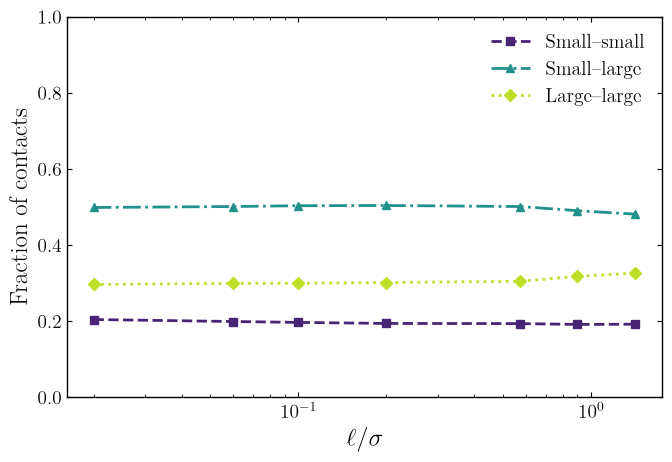

In [10]:
contact_types = {
    "ss": ("Small--small", "s", "--"),
    "sl": ("Small--large", "^", "-."),
    "ll": ("Large--large", "D", ":"),
}

order = np.argsort(l_over_sigma)
x = l_over_sigma[order]
colors = plt.get_cmap("viridis")(np.linspace(0.1, 0.9, len(contact_types)))

fig, ax = plt.subplots(figsize=(7, 4.9))

for (key, (label, marker, linestyle)), color in zip(contact_types.items(), colors):
    fractions = np.array([
        len(data[value][key]) / len(data[value]["all"])
        for value in mu_eff
    ])[order]

    ax.plot(
        x,
        fractions,
        color=color,
        marker=marker,
        linestyle=linestyle,
        label=label,
    )

ax.set_xlabel(r"$\ell/\sigma$")
ax.set_ylabel(r"Fraction of contacts")
ax.set_ylim(0, 1)
ax.set_xscale("log") 
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../../figures/friction/uniform/fraction-contacts.png", dpi=600, bbox_inches="tight")
plt.show()

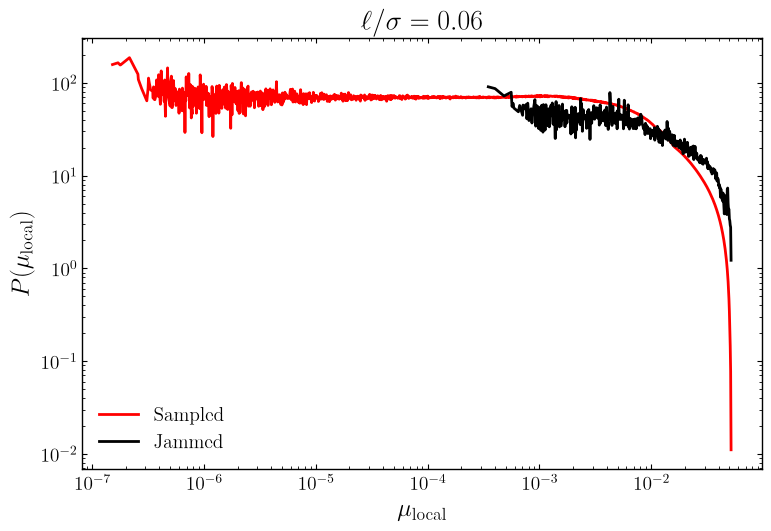

In [11]:
selected_l_over_sigma = 0.059
min_count = 10

index = np.argmin(np.abs(l_over_sigma - selected_l_over_sigma))
value = mu_eff[index]
ratio = l_over_sigma[index]

jammed = jammed_data[value]
sampled = sampled_data[value]

positive_values = np.concatenate([
    positive(jammed["all"]),
    positive(sampled["ss"]),
    positive(sampled["sl"]),
    positive(sampled["ll"]),
])

bins = np.logspace(
    np.log10(positive_values.min()),
    np.log10(positive_values.max()),
    2000,
)

centers = np.sqrt(bins[:-1] * bins[1:])

def density(values):
    values = positive(values)
    counts, _ = np.histogram(values, bins=bins)
    probability = counts / (len(values) * np.diff(bins))
    return probability, counts

jammed_probability, jammed_counts = density(jammed["all"])

sampled_parts = [
    (
        len(jammed[key]) / len(jammed["all"]),
        *density(sampled[key]),
    )
    for key in ("ss", "sl", "ll")
]

sampled_probability = sum(
    weight * probability
    for weight, probability, counts in sampled_parts
)

sampled_counts = sum(
    counts
    for weight, probability, counts in sampled_parts
)

jammed_mask = jammed_counts >= min_count
sampled_mask = sampled_counts >= min_count

fig, ax = plt.subplots()

ax.plot(
    centers[sampled_mask],
    sampled_probability[sampled_mask],
    color="red",
    linestyle="-",
    label="Sampled",
)

ax.plot(
    centers[jammed_mask],
    jammed_probability[jammed_mask],
    color="black",
    linestyle="-",
    label="Jammed",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\mu_{\mathrm{local}}$")
ax.set_ylabel(r"$P(\mu_{\mathrm{local}})$")
ax.set_title(rf"$\ell/\sigma={ratio:.3g}$")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

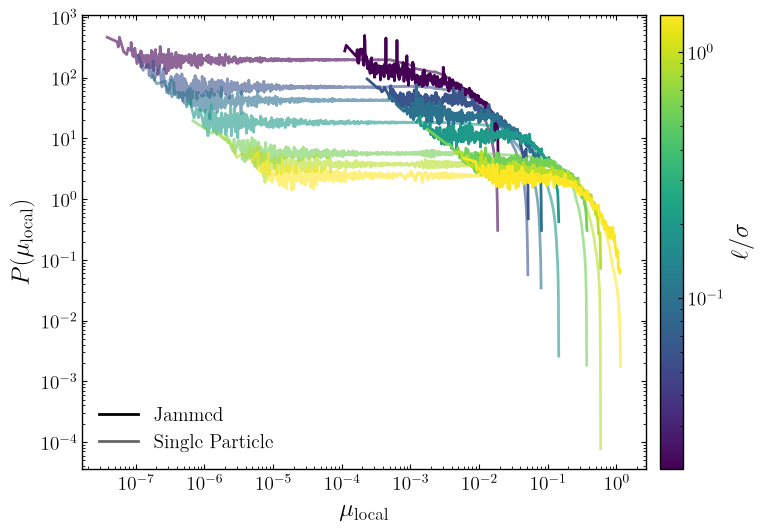

: 

In [ ]:
from matplotlib.colors import LogNorm

l_over_sigma = 2 * mu_eff / np.sqrt(1 + mu_eff**2)
min_count = 10

def positive(values):
    return values[np.isfinite(values) & (values > 0)]

positive_values = np.concatenate([
    positive(jammed_data[value]["all"])
    for value in mu_eff
] + [
    positive(sampled_data[value][key])
    for value in mu_eff
    for key in ("ss", "sl", "ll")
])

bins = np.logspace(
    np.log10(positive_values.min()),
    np.log10(positive_values.max()),
    2000,
)

centers = np.sqrt(bins[:-1] * bins[1:])
norm = LogNorm(l_over_sigma.min(), l_over_sigma.max())
cmap = plt.get_cmap("viridis")

def density(values):
    values = positive(values)
    counts, _ = np.histogram(values, bins=bins)
    probability = counts / (len(values) * np.diff(bins))
    return probability, counts

fig, ax = plt.subplots()

for value, ratio in zip(mu_eff, l_over_sigma):
    color = cmap(norm(ratio))

    sampled_parts = {
        key: density(sampled_data[value][key])
        for key in ("ss", "sl", "ll")
    }

    sampled_probability = sum(
        len(jammed_data[value][key]) / len(jammed_data[value]["all"])
        * sampled_parts[key][0]
        for key in ("ss", "sl", "ll")
    )

    sampled_counts = sum(
        sampled_parts[key][1]
        for key in ("ss", "sl", "ll")
    )

    sampled_mask = sampled_counts >= min_count

    ax.plot(
        centers[sampled_mask],
        sampled_probability[sampled_mask],
        color=color,
        alpha=0.6,
        zorder=1,
    )

for value, ratio in zip(mu_eff, l_over_sigma):
    color = cmap(norm(ratio))

    jammed_probability, jammed_counts = density(jammed_data[value]["all"])
    jammed_mask = jammed_counts >= min_count

    ax.plot(
        centers[jammed_mask],
        jammed_probability[jammed_mask],
        color=color,
        alpha=1.0,
        zorder=2,
    )

handles = [
    ax.plot([], [], color="black", alpha=1.0, label="Jammed")[0],
    ax.plot([], [], color="black", alpha=0.6, label="Single Particle")[0],
]

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    pad=0.02,
)

colorbar.set_label(r"$\ell/\sigma$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\mu_{\mathrm{local}}$")
ax.set_ylabel(r"$P(\mu_{\mathrm{local}})$")
ax.legend(handles=handles, frameon=False)
plt.tight_layout()
plt.savefig("../../figures/friction/uniform/combined-distributions.png", dpi=600, bbox_inches="tight")
plt.show()